In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
import matplotlib.pyplot as plt
import contextily as cx
from sklearn.metrics import silhouette_score


In [2]:
data_df = pd.read_csv("./data_by_date.csv")
data_df

,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,EDAD,...,x,y,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD
0,2010-01-30,1,1,217,231,6261,0,61,hombre,35,...,-110.958961,29.129075,NaN,30,4,1,2010,30,1,0
1,2010-05-06,3,1,219,233,6425,0,296,hombre,14,...,-110.965989,29.131731,NaN,6,18,5,2010,126,1,0
2,2010-05-09,2,1,218,232,6424,0,295,mujer,38,...,-110.965989,29.131733,NaN,9,18,5,2010,129,1,0
3,2010-06-04,4,1,220,234,6497,0,427,mujer,22,...,-110.979272,29.124453,NaN,4,22,6,2010,155,0,1
4,2010-07-04,6,2,222,236,6581,0,546,hombre,12,...,-110.963284,29.138764,NaN,4,26,7,2010,185,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2723,2010-12-28,2345,2,2562,2688,11089,0,5648,mujer,66,...,-110.959993,29.113262,NaN,28,52,12,2010,362,1,0
2724,2010-12-28,2348,1,2565,2691,11093,0,5652,mujer,7,...,-110.943367,29.084639,NaN,28,52,12,2010,362,0,1
2725,2010-12-31,2352,1,2569,2695,11113,0,5676,mujer,41,...,-110.961561,29.136562,NaN,31,52,12,2010,365,1,0
2726,2010-12-31,2353,1,2570,2696,11114,0,5677,hombre,38,...,-110.955553,29.072824,NaN,31,52,12,2010,365,1,0


In [3]:
data_df = data_df[data_df["I_CUADRO"] > "2010-08-28"]


In [4]:
gdf = gpd.GeoDataFrame(
    data_df, geometry=gpd.points_from_xy(data_df["x"], data_df["y"]), crs="EPSG:4326"
)

In [5]:
X = data_df[["x", "y", "SEXO", "EDAD", "GRADO_MA_1", "DENSI_POB", "week", "FD_FHD"]]
X.set_index(np.arange(len(X)), inplace=True)

sexo_df = pd.get_dummies(X["SEXO"], dtype="int", drop_first=True)
X = pd.concat([X, sexo_df], axis=1)
X.drop("SEXO", axis=1, inplace=True)

fd_fhd_df = pd.get_dummies(X["FD_FHD"], dtype="int", drop_first=True)
X = pd.concat([X, fd_fhd_df], axis=1)
X.drop("FD_FHD", axis=1, inplace=True)

X.columns = ["x", "y", "edad", "grad_marg", "densi_pob", "semana", "sexo", "FHD"]

X.head()

,x,y,edad,grad_marg,densi_pob,semana,sexo,FHD
0,-111.015505,29.134184,0,3,77.445107,35,1,1
1,-110.964347,29.136228,41,3,122.000382,35,0,1
2,-110.966473,29.137403,47,3,122.000382,35,1,0
3,-110.964142,29.137217,8,3,122.000382,35,0,0
4,-110.967696,29.126753,30,2,83.995697,35,0,0


In [6]:
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

standard_scaled_df = pd.DataFrame(standard_scaler.fit_transform(X.drop(["sexo", "grad_marg", "semana", "FHD"], axis=1)))
min_max_scaled_df = pd.DataFrame(min_max_scaler.fit_transform(X[["grad_marg", "semana"]]))

standard_scaled_df.columns = ["x", "y", "edad", "densi_pob"]
min_max_scaled_df.columns = ["grad_marg", "semana"]

In [7]:
X = pd.concat([standard_scaled_df, min_max_scaled_df, X["sexo"]], axis=1)
X.head()

,x,y,edad,densi_pob,grad_marg,semana,sexo
0,-1.700815,0.707979,-1.704933,-0.014793,0.50,0.0,1
1,0.620166,0.777090,0.462566,1.490939,0.50,0.0,0
2,0.523707,0.816815,0.779761,1.490939,0.50,0.0,1
3,0.629439,0.810517,-1.282006,1.490939,0.50,0.0,0
4,0.468217,0.456710,-0.118958,0.206582,0.25,0.0,0


In [8]:
X.isna().sum()

x            0
y            0
edad         0
densi_pob    0
grad_marg    0
semana       0
sexo         0
dtype: int64

## Kmeans

In [64]:
n_clusters_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
kmeans_list = []
silhouette_scores_list = []

for n_clusters in n_clusters_list:
    kmeans = KMeans(n_clusters=n_clusters).fit(X)
    kmeans_list.append(kmeans)
    silhouette_scores_list.append(silhouette_score(X, kmeans.predict(X)))

In [65]:
silhouette_scores_list

[0.2897951383529283,
 0.23796609038811473,
 0.23390491035581026,
 0.21245739395806107,
 0.2150380531493352,
 0.2072571072534678,
 0.22440668867331426,
 0.21524095640920168,
 0.1871045914216257]

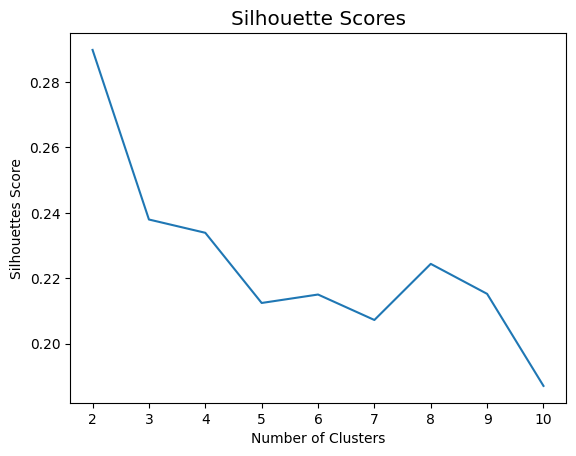

In [68]:
plt.plot(n_clusters_list, silhouette_scores_list)
plt.style.use('ggplot')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouettes Score")
plt.savefig("silhouette_score.png")
plt.show()

In [45]:
n_clusters = 2

best_kmeans = kmeans_list[n_clusters - 2]
best_kmeans_labels = best_kmeans.labels_

/tmp/ipykernel_19186/1650269724.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df["cluster_kmeans"] = clusters


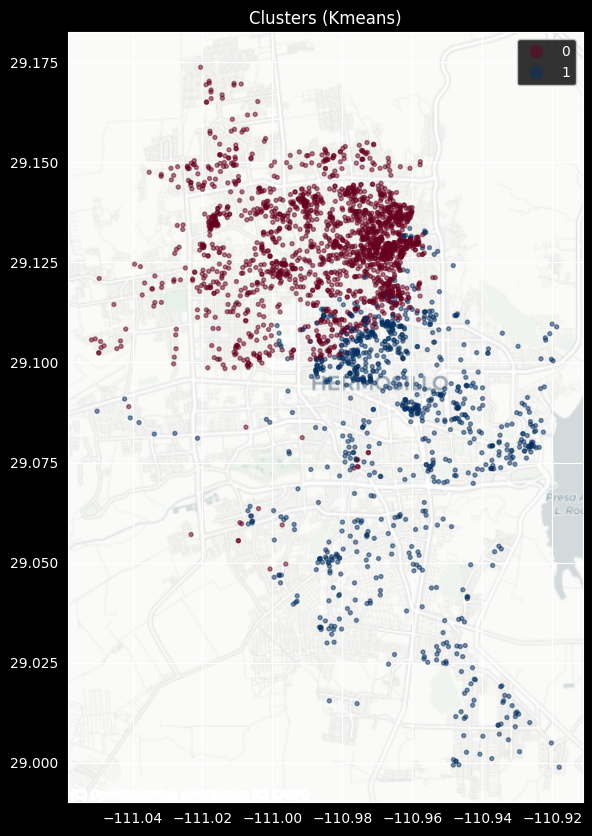

In [46]:
clusters = pd.Categorical(best_kmeans_labels, categories=set(best_kmeans_labels), ordered=False)
data_df["cluster_kmeans"] = clusters
gdf["cluster_kmeans"] = clusters

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="cluster_kmeans", legend=True, cmap='RdBu', markersize=8)
ax.set_title("Clusters (Kmeans)")

cx.add_basemap(ax=ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

#filename = 'mapa_kmeans_sec_1.png'
#plt.savefig(os.path.join(folder,filename))
#kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


<Axes: xlabel='cluster_kmeans'>

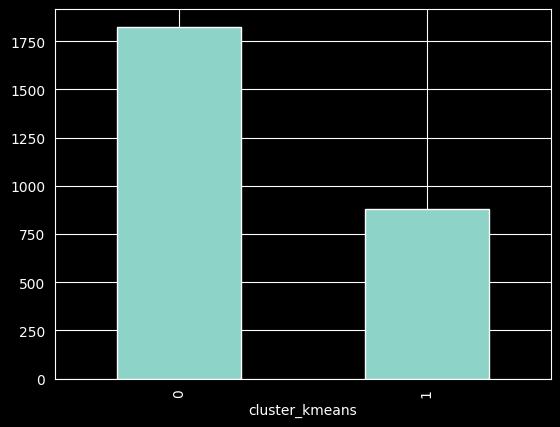

In [47]:
counts = gdf["cluster_kmeans"].value_counts()
counts.sort_index(inplace=True)
counts.plot(kind="bar")


In [62]:
gdf.columns

Index(['I_CUADRO', 'OBJECTID', 'Join_Count', 'TARGET_FID', 'ID_HILLO',
       'ID_SON', 'ANYO', 'FOLIO', 'SEXO', 'EDAD', 'D_H_', 'U_NOTIFICA', 'J_N_',
       'DOMICILIO', 'COLONIA', 'LOCALIDAD', 'MUNICIPIO', 'I_CUADRO2',
       'S_E__INICI', 'J_S_', 'HOSP', 'HEMORRAGIA', 'PLAQUETAS', 'DEFUNCION',
       'FOLIO_DENG', 'DIAS_EVOLU', 'IgM_ELISA', 'IgG_ELISA', 'NS1',
       'AISLAMIENT', 'FD_FHD', 'DIAGNOSTIC', 'OBSERVACIO', 'ID_HILLO_1',
       'EDAD2', 'CUANTIFICA', 'GRAVE', 'CVEGEO', 'CVEGEO_1', 'POB1', 'POB26_R',
       'POB27_R', 'POB30_R', 'ECO25_R', 'SALUD2_R', 'EDU34_R', 'MIG11_R',
       'VIV2_R', 'VIV4_R', 'VIV9_R', 'VIV17_R', 'VIV26_R', 'VIV27_R',
       'VIV28_R', 'VIV31_R', 'VIV32_R', 'VIV33_R', 'VIV34_R', 'VIV35_R',
       'VIV36_R', 'GRADO_MARG', 'GRADO_MA_1', 'hectarea', 'DENSI_POB', 'VIV2',
       'INDEX_NORM', 'INDEX_NO_1', 'x', 'y', 'Unnamed: 69', 'day', 'week',
       'month', 'year', 'dayofyear', 'FD', 'FHD', 'geometry', 'cluster_kmeans',
       'cluster_dbscan', 'clus

In [48]:
gdf.to_csv("gdf_clustered.csv")

## DBSCAN

In [49]:
eps_list = [0.3, 0.4, 0.5, 0.6, 0.7]
dbscan_list = []
silhouette_scores_list = []

for eps in eps_list:
    dbscan = DBSCAN(eps=eps, min_samples=10).fit(X)
    dbscan_list.append(dbscan)
    silhouette_scores_list.append(silhouette_score(X, dbscan.labels_))

In [50]:
silhouette_scores_list

[-0.3594975420280109,
 -0.31317982014378565,
 -0.2901042941924202,
 -0.2265023351009585,
 -0.040783460330729916]

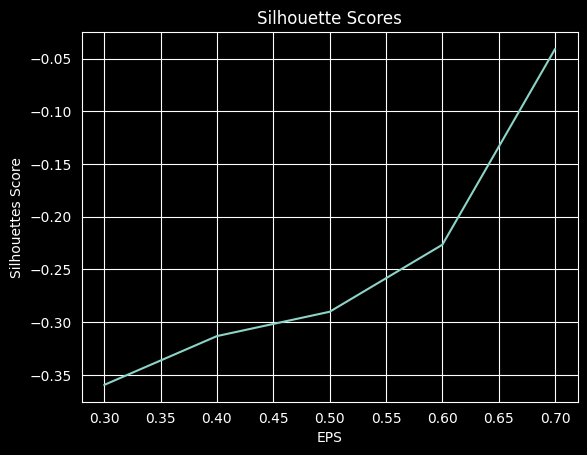

In [51]:
plt.plot(eps_list, silhouette_scores_list)
plt.title("Silhouette Scores")
plt.xlabel("EPS")
plt.ylabel("Silhouettes Score")
plt.show()

In [52]:
eps = 0.7

idx = eps_list.index(eps)
best_dbscan = dbscan_list[idx]
best_dbscan_labels = best_dbscan.labels_

In [ ]:
clusters = pd.Categorical(best_dbscan_labels, categories=set(best_dbscan_labels), ordered=False)
data_df["cluster_dbscan"] = clusters
gdf["cluster_dbscan"] = clusters

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="cluster_dbscan", legend=True, cmap='viridis', markersize=8)
ax.set_title("Clusters (DBSCAN)")

cx.add_basemap(ax=ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

#filename = 'mapa_kmeans_sec_1.png'
#plt.savefig(os.path.join(folder,filename))
#kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


<Axes: xlabel='cluster_dbscan'>

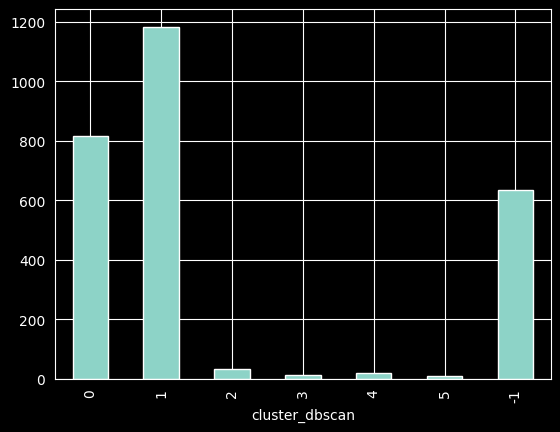

In [54]:
counts = gdf["cluster_dbscan"].value_counts()
counts.sort_index(inplace=True)
counts.plot(kind="bar")


## HDBSCAN

In [55]:
min_cluster_size_list = [10, 20, 30 , 40, 50, 60]
hdbscan_list = []
silhouette_scores_list = []

for min_cluster_size in min_cluster_size_list:
    hdbscan = HDBSCAN(min_cluster_size=min_cluster_size).fit(X)
    hdbscan_list.append(hdbscan)
    silhouette_scores_list.append(silhouette_score(X, hdbscan.labels_))

In [56]:
silhouette_scores_list

[-0.007738517955111041,
 0.053716806928691636,
 0.043610902700531196,
 0.02937424580635376,
 0.01736229173423429,
 0.002912886682028789]

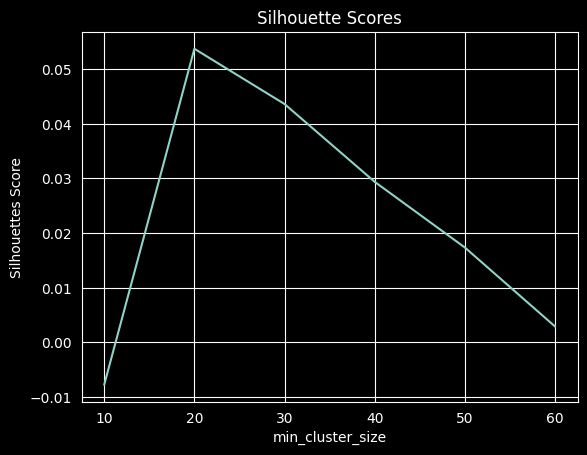

In [57]:
plt.plot(min_cluster_size_list, silhouette_scores_list)
plt.title("Silhouette Scores")
plt.xlabel("min_cluster_size")
plt.ylabel("Silhouettes Score")
plt.show()

In [58]:
min_cluster_size = 20

idx = min_cluster_size_list.index(min_cluster_size)
best_hdbscan = hdbscan_list[idx]
best_hdbscan_labels = best_hdbscan.labels_

/tmp/ipykernel_19186/687808256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df["cluster_hdbscan"] = clusters


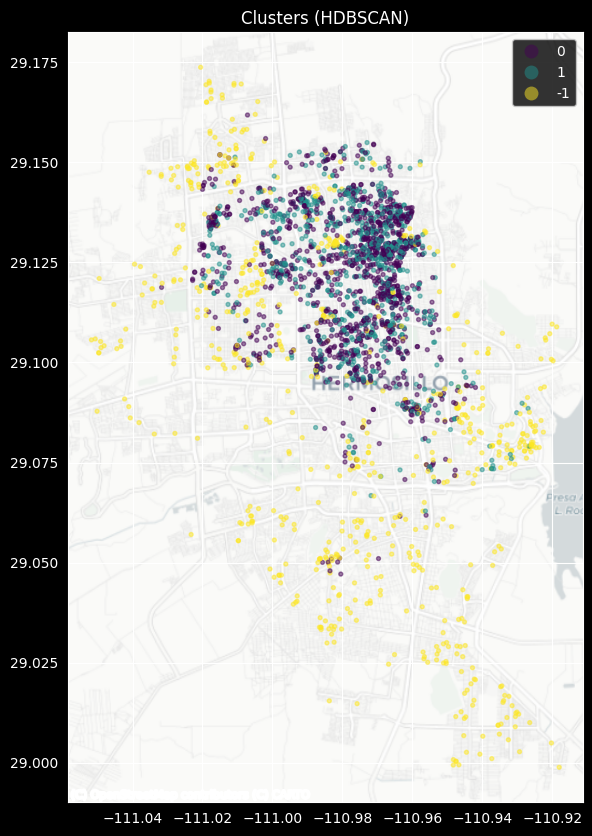

In [59]:
clusters = pd.Categorical(best_hdbscan_labels, categories=set(best_hdbscan_labels), ordered=False)
data_df["cluster_hdbscan"] = clusters
gdf["cluster_hdbscan"] = clusters

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="cluster_hdbscan", legend=True, cmap='viridis', markersize=8)
ax.set_title("Clusters (HDBSCAN)")

cx.add_basemap(ax=ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

#filename = 'mapa_kmeans_sec_1.png'
#plt.savefig(os.path.join(folder,filename))
#kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


<Axes: xlabel='cluster_hdbscan'>

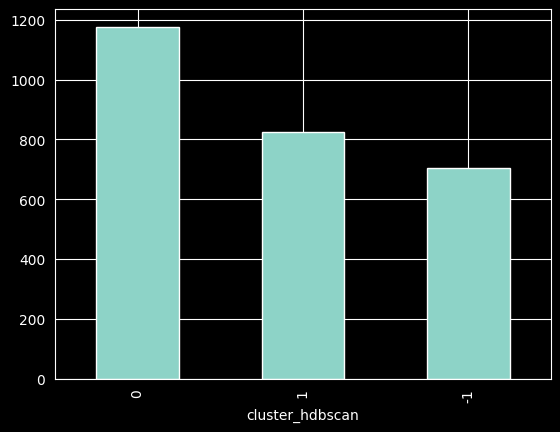

In [60]:
counts = gdf["cluster_hdbscan"].value_counts()
counts.sort_index(inplace=True)
counts.plot(kind="bar")
